# Step 1 — Data Exploration & DataViz
## Dataset B — PlantVillage (raw, disease classification)

This notebook explores the **raw PlantVillage** dataset (the untouched `abdallahalidev` images, 38 crop/disease classes) for the disease half of the project. It uses the **same metadata-table method and the same section layout** as the augmented-variant notebook, so the two read side by side.

**Why exploration comes first.** In any ML project the first job is to *understand the data before modelling* — its structure, its biases, and whether simple signals are already enough. Every cell below carries a short note on **why we run it** and **how it fits** that goal, and each figure ends with a one-line **takeaway**. The findings here are what justify every preprocessing and modelling choice we make later.

**Raw vs augmented.** The raw set has **no train/valid split** (we build our own) and is **strongly imbalanced (~36:1)**; the augmented set is pre-split and balanced. The images themselves are identical. Paths are auto-discovered and the heavy steps are cached, so re-runs are instant.

## Colab setup — run this first

On **Google Colab** the dataset is pulled from Kaggle, which needs your Kaggle API key. We use **Colab Secrets** so the key never lives in the notebook:

1. Open your `kaggle.json` (it reads `{"username": "...", "key": "..."}`).
2. In the left sidebar, click the **key icon (Secrets)** → **Add new secret** twice, each with **Notebook access** turned on: `KAGGLE_USERNAME` (your username) and `KAGGLE_KEY` (your key).
3. Run the cell below, then **Runtime ▸ Run all**.

Each teammate stores their own two secrets — nothing else to change. *(Run locally, this cell does nothing and the notebook uses your local `~/.kaggle/kaggle.json` instead.)*

In [ ]:
# Colab: load Kaggle credentials from Colab Secrets. Harmless when run locally.
import os
try:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    print("Kaggle credentials loaded from Colab Secrets.")
except ModuleNotFoundError:
    pass  # not on Colab - falls back to local ~/.kaggle/kaggle.json


Kaggle credentials loaded from Colab Secrets.


## 0. Setup

Imports, a fixed random seed, the two file paths, and two small helpers.

**Why run it:** a Jupyter kernel forgets every variable when it restarts, so this must run first or nothing below works; the fixed seed (`random.seed(42)`) makes the later random sample reproducible.

**How it fits:** reproducibility — same seed, same results — is a basic requirement of trustworthy, defensible data science.

In [ ]:
# Imports, theme, paths, and small helpers
from pathlib import Path
from collections import deque
import time, random
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
sns.set_theme(); random.seed(42)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", None)

PV_DIR   = Path.home() / "plant_recognition" / "plantvillage"
PV_META  = Path.home() / "plant_recognition" / "metadata_plantvillage.csv"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

def locate(root, names, max_depth=4):
    # breadth-first search for the first sub-directory whose name matches
    q = deque([(root, 0)])
    while q:
        d, depth = q.popleft()
        if d.is_dir() and d.name.lower() in names:
            return d
        if d.is_dir() and depth < max_depth:
            for c in sorted(d.iterdir()):
                if c.is_dir():
                    q.append((c, depth + 1))
    return None

def class_counts(folder):
    dirs = sorted([d for d in folder.iterdir() if d.is_dir()])
    return pd.Series(
        {d.name: sum(1 for f in d.rglob("*") if f.suffix.lower() in IMG_EXTS) for d in dirs}
    ).sort_values(ascending=False)

## 1. Download

Fetches the dataset from Kaggle, and **skips if it is already on disk**.

**Why run it:** we need the raw images locally before we can look at them; the skip-guard means re-running the notebook is instant and never re-downloads gigabytes.

**How it fits:** starting from the *original, untouched* source (not a pre-processed copy) keeps every later step under our control — clean data provenance.

In [ ]:
# Download raw PlantVillage from Kaggle (skips if PV_DIR is non-empty; needs kaggle.json)
if not PV_DIR.exists() or not any(PV_DIR.iterdir()):
    from kaggle.api.kaggle_api_extended import KaggleApi
    PV_DIR.mkdir(parents=True, exist_ok=True)
    api = KaggleApi(); api.authenticate()
    api.dataset_download_files("abdallahalidev/plantvillage-dataset",
                               path=str(PV_DIR), unzip=True, quiet=False)
    print("Downloaded to", PV_DIR)
else:
    print("Already present:", PV_DIR)

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:23<00:00, 94.9MB/s]



Downloaded to /root/plant_recognition/plantvillage


## 2. Folder structure

The archive ships **three renderings** of the same photos — `color`, `grayscale`, `segmented` — nested inside a wrapper folder. This cell finds the `color` copy automatically and confirms the 38 classes.

**Why run it:** you must know how the data is laid out before reading it; here it is nested and comes in three forms, so we locate the right one instead of hard-coding a fragile path.

**How it fits:** the first task of exploration is to understand the dataset's structure and spot its quirks (the three renderings) before any analysis.

In [ ]:
# Locate the COLOR rendering (robust to the wrapper folder) and report the structure
COLOR_DIR = locate(PV_DIR, {"color"})
assert COLOR_DIR is not None, "Could not find a 'color' folder under PV_DIR - check the path."
WRAPPER = COLOR_DIR.parent          # the folder that holds color/ grayscale/ segmented
print("color dir:", COLOR_DIR)

reps = sorted([d.name for d in WRAPPER.iterdir() if d.is_dir()])
print("renderings present:", reps)
color_classes = sorted([d.name for d in COLOR_DIR.iterdir() if d.is_dir()])
print(f"color classes: {len(color_classes)}")

color dir: /root/plant_recognition/plantvillage/plantvillage dataset/color
renderings present: ['color', 'grayscale', 'segmented']
color classes: 38


## 3. Class counts + sampled metadata

Counts every image (fast), then samples 250 per class and turns each sampled image into a **row of numbers** — size, colour, file size — cached to CSV.

**Why run it:** our tools (pandas, charts, statistics) work on **tables, not image files**, so we build a metadata table that bridges the two. Sampling keeps the colour scan to seconds instead of minutes.

**How it fits:** turning raw images into a clean table is the foundation step that makes every visualization and statistical test below possible.

In [ ]:
# Full class counts (fast) + a 250/class sample for pixel features (cached)
counts_pv  = class_counts(COLOR_DIR)
class_dirs = sorted([d for d in COLOR_DIR.iterdir() if d.is_dir()])
print(f"{len(counts_pv)} classes, {counts_pv.sum():,} images (color).")

if PV_META.exists():
    pv = pd.read_csv(PV_META)
    print("Loaded cached metadata:", pv.shape)
else:
    PER_CLASS, records, t0 = 250, [], time.time()
    for d in class_dirs:
        files = [f for f in d.rglob("*") if f.suffix.lower() in IMG_EXTS]
        for fp in random.sample(files, min(PER_CLASS, len(files))):
            try:
                img = mpimg.imread(fp).astype("float64")
                if img.max() <= 1.0:
                    img *= 255.0
                if img.ndim == 2:
                    h, w = img.shape; ch = 1; r = g = b = br = float(img.mean())
                else:
                    h, w, ch = img.shape
                    r, g, b = (float(img[:, :, i].mean()) for i in range(3))
                    br = float(img[:, :, :3].mean())
                records.append({"filepath": str(fp), "label": d.name,
                                "width": w, "height": h, "aspect_ratio": w/h,
                                "n_pixels": w*h, "channels": ch,
                                "file_size_kb": fp.stat().st_size/1024,
                                "brightness": br, "mean_R": r, "mean_G": g, "mean_B": b})
            except Exception:
                pass
    pv = pd.DataFrame(records)
    pv["crop"]       = pv["label"].str.split("___").str[0]
    pv["condition"]  = pv["label"].str.split("___").str[1]
    pv["is_healthy"] = pv["condition"].str.lower().eq("healthy")
    pv.to_csv(PV_META, index=False)
    print(f"Built metadata: {pv.shape} in {time.time()-t0:.0f}s, cached to {PV_META}")

print("Crops:", pv["crop"].nunique(), "| healthy rows:", int(pv["is_healthy"].sum()), "/", len(pv))

38 classes, 54,305 images (color).
Built metadata: (9402, 15) in 15s, cached to /root/plant_recognition/metadata_plantvillage.csv
Crops: 14 | healthy rows: 2902 / 9402


## 4. Data-audit table

One row per column: its type, % missing, distribution, and a short modelling note.

**Why run it:** it is a systematic, at-a-glance description of the whole dataset and confirms there is no missing or broken data before we rely on it.

**How it fits:** a data audit is a standard exploration deliverable — it documents *what we have* and flags issues early, which the project report requires.

In [ ]:
# Data-audit table for PlantVillage (saved as .xlsx).
# Class counts use the FULL data (counts_pv); pixel stats use the SAMPLE (pv).
audit_info = {
 "filepath":     ("Absolute path to the image; unique id.", "Identifier (text)",
                  lambda c: f"{pv[c].nunique()} sampled paths.",
                  "Not predictive; used to load the image."),
 "label":        ("Full class crop___condition - the 38-class disease TARGET.", "Categorical (target)",
                  lambda c: f"38 classes; full data {counts_pv.max():,} (max) to {counts_pv.min()} (min).",
                  "Extreme imbalance ~36:1. Predict this (or crop + condition)."),
 "crop":         ("Plant type parsed from the label.", "Categorical",
                  lambda c: f"{pv[c].nunique()} crops; Tomato is the largest.",
                  "Entangled with disease; several crops are single-condition."),
 "condition":    ("Specific condition / disease name parsed from the label.", "Categorical",
                  lambda c: f"{pv[c].nunique()} distinct conditions.",
                  "Fine-grained disease label."),
 "is_healthy":   ("True when the condition is exactly 'healthy'.", "Categorical (boolean)",
                  lambda c: f"{pv[c].mean()*100:.0f}% healthy (sample).",
                  "Core healthy/diseased axis; meaningful only for crops with both."),
 "width":        ("Image width in pixels.", "Quantitative (discrete)",
                  lambda c: f"constant {int(pv[c].iloc[0])} px.",
                  "Uniform -> no resizing needed within this dataset."),
 "height":       ("Image height in pixels.", "Quantitative (discrete)",
                  lambda c: f"constant {int(pv[c].iloc[0])} px.",
                  "Uniform; images are 256x256."),
 "aspect_ratio": ("Width / height.", "Quantitative (continuous)",
                  lambda c: f"constant {pv[c].iloc[0]:.0f}.",
                  "Square -> no distortion from a square resize."),
 "n_pixels":     ("Width x height (resolution).", "Quantitative (discrete)",
                  lambda c: f"constant {int(pv[c].iloc[0]):,}.",
                  "Uniform resolution."),
 "channels":     ("Number of colour channels.", "Categorical",
                  lambda c: f"constant {int(pv[c].iloc[0])} (RGB).",
                  "Already standardized to 3 channels."),
 "file_size_kb": ("File size on disk (KB).", "Quantitative (continuous)",
                  lambda c: f"min {pv[c].min():.0f}, median {pv[c].median():.0f}, max {pv[c].max():.0f} KB.",
                  "On fixed-size JPEGs, larger ~ more detail; weak signal."),
 "brightness":   ("Mean pixel intensity (0-255).", "Quantitative (continuous)",
                  lambda c: f"mean {pv[c].mean():.0f} of 255.",
                  "Controlled lab lighting; fairly uniform."),
 "mean_R":       ("Mean of the red channel.", "Quantitative (continuous)",
                  lambda c: f"mean {pv[c].mean():.0f}.", "Colour highly redundant with brightness."),
 "mean_G":       ("Mean of the green channel.", "Quantitative (continuous)",
                  lambda c: f"mean {pv[c].mean():.0f}.", "Dominant channel (foliage)."),
 "mean_B":       ("Mean of the blue channel.", "Quantitative (continuous)",
                  lambda c: f"mean {pv[c].mean():.0f}.", "Lowest channel."),
}

pv_audit = pd.DataFrame([{
    "#": i,
    "Name of the Column": col,
    "Description": desc,
    "Variable's type": str(pv[col].dtype),
    "Percentage of missing values": f"{pv[col].isna().mean()*100:.1f}%",
    "Categorical / Quantitative": kind,
    "Distribution": dist(col),
    "Comments": note,
} for i, (col, (desc, kind, dist, note)) in enumerate(audit_info.items(), start=1)])

pv_audit.to_excel(Path.home() / "plant_recognition" / "DATA_AUDIT_plantvillage.xlsx", index=False)
pv_audit

,#,Name of the Column,Description,Variable's type,Percentage of missing values,Categorical / Quantitative,Distribution,Comments
0,1,filepath,Absolute path to the image; unique id.,object,0.0%,Identifier (text),9402 sampled paths.,Not predictive; used to load the image.
1,2,label,Full class crop___condition - the 38-class dis...,object,0.0%,Categorical (target),"38 classes; full data 5,507 (max) to 152 (min).",Extreme imbalance ~36:1. Predict this (or crop...
2,3,crop,Plant type parsed from the label.,object,0.0%,Categorical,14 crops; Tomato is the largest.,Entangled with disease; several crops are sing...
3,4,condition,Specific condition / disease name parsed from ...,object,0.0%,Categorical,21 distinct conditions.,Fine-grained disease label.
4,5,is_healthy,True when the condition is exactly 'healthy'.,bool,0.0%,Categorical (boolean),31% healthy (sample).,Core healthy/diseased axis; meaningful only fo...
5,6,width,Image width in pixels.,int64,0.0%,Quantitative (discrete),constant 256 px.,Uniform -> no resizing needed within this data...
6,7,height,Image height in pixels.,int64,0.0%,Quantitative (discrete),constant 256 px.,Uniform; images are 256x256.
7,8,aspect_ratio,Width / height.,float64,0.0%,Quantitative (continuous),constant 1.,Square -> no distortion from a square resize.
8,9,n_pixels,Width x height (resolution).,int64,0.0%,Quantitative (discrete),"constant 65,536.",Uniform resolution.
9,10,channels,Number of colour channels.,int64,0.0%,Categorical,constant 3 (RGB).,Already standardized to 3 channels.


## 5. Visualizations & statistical tests

This is the heart of the exploration: each figure pairs a **picture** (the business reading) with a **statistical test** (a number that confirms what the picture suggests) — the pattern the project asks for.

### Figure 1 — Class distribution (chi-square goodness-of-fit)

**What / why:** a bar chart plus a chi-square test of the 38 class sizes — we need to know if the classes are balanced, because imbalance changes how we train and *score* the model.

**How it fits:** class balance is a key bias to surface in exploration; it directly drives modelling choices (which metrics to use, whether to weight classes).

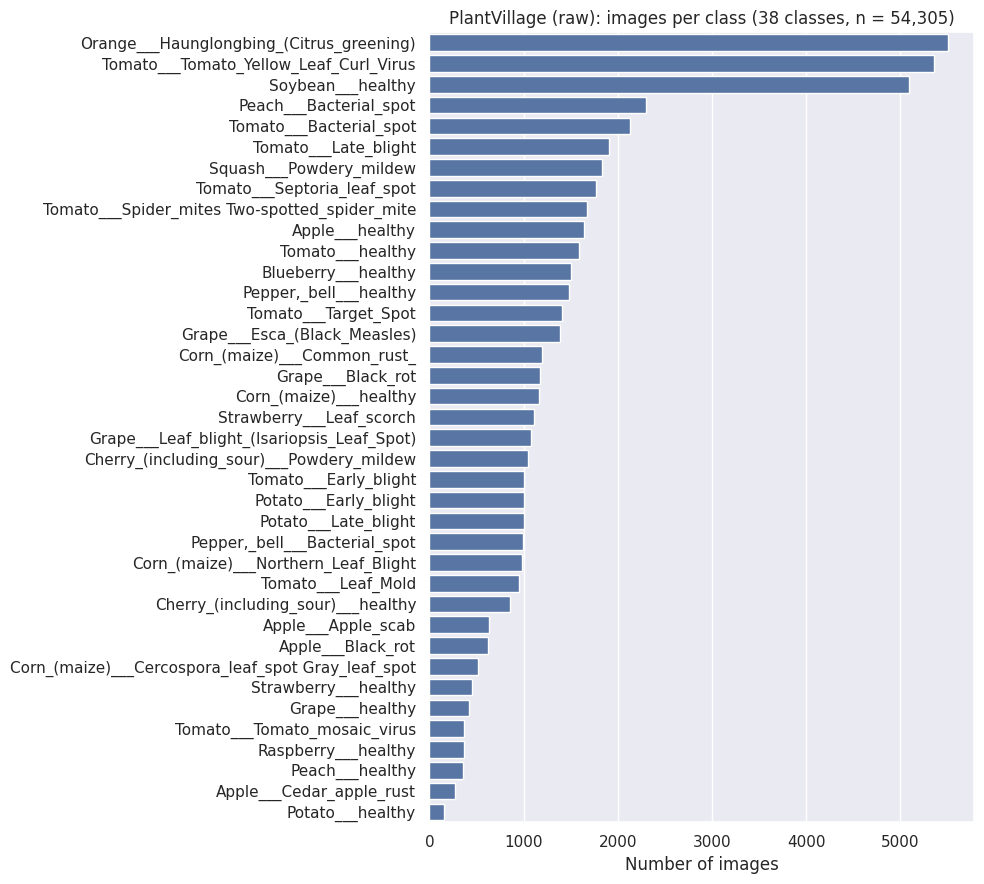

Imbalance ratio (max/min): 36.2 : 1
Chi-square vs uniform: chi2 = 41874, p = 0.00e+00


In [ ]:
# Figure 1 - class distribution (38 classes) + chi-square goodness-of-fit
from scipy.stats import chisquare

plt.figure(figsize=(10, 9))
sns.barplot(x=counts_pv.values, y=counts_pv.index, color="#4c72b0")
plt.xlabel("Number of images"); plt.ylabel("")
plt.title(f"PlantVillage (raw): images per class (38 classes, n = {counts_pv.sum():,})")
plt.tight_layout(); plt.show()

print(f"Imbalance ratio (max/min): {counts_pv.max()/counts_pv.min():.1f} : 1")
chi2, p = chisquare(f_obs=counts_pv.values, f_exp=[counts_pv.sum()/len(counts_pv)]*len(counts_pv))
print(f"Chi-square vs uniform: chi2 = {chi2:.0f}, p = {p:.2e}")

**Takeaway:** the classes are very unequal (**36:1**). Plain accuracy would be misleading, so we will use **macro-F1 / per-class recall** and balance the classes ourselves when training.

### Figure 2 — Data integrity: the three renderings

**What / why:** confirm that `color`, `grayscale` and `segmented` are the **same images** (same classes and counts) and show one example of each — so we know that using `color` loses no data and isn't silently duplicating it.

**How it fits:** a data-integrity check — verifying a structural quirk before trusting the data — is exactly the kind of validation good exploration does. (It is the raw-set parallel to checking a *provided* train/valid split.)

renderings: ['color', 'grayscale', 'segmented']
same classes in every rendering: True
per-class counts identical across renderings: False

Total images per rendering:
color        54305
grayscale    54305
segmented    54306


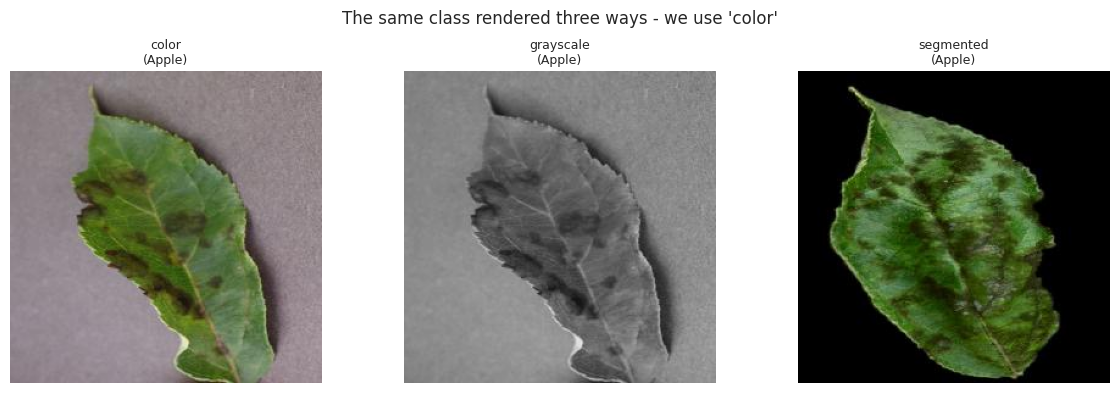

In [ ]:
# Figure 2 - data integrity: confirm the three renderings are the same images
reps_present = [r for r in ["color", "grayscale", "segmented"] if (WRAPPER / r).is_dir()]
rep_counts = pd.DataFrame({r: class_counts(WRAPPER / r) for r in reps_present}).fillna(0).astype(int)

print("renderings:", reps_present)
print("same classes in every rendering:",
      all(set(rep_counts.index) == set(class_counts(WRAPPER / r).index) for r in reps_present))
print("per-class counts identical across renderings:",
      bool((rep_counts.nunique(axis=1) == 1).all()))
print("\nTotal images per rendering:")
print(rep_counts.sum().to_string())

# one example from each rendering (same class) to show what they look like
demo_class = color_classes[0]
fig, axes = plt.subplots(1, len(reps_present), figsize=(4 * len(reps_present), 4))
for ax, r in zip(np.atleast_1d(axes), reps_present):
    files = [f for f in (WRAPPER / r / demo_class).rglob("*") if f.suffix.lower() in IMG_EXTS]
    if files:
        ax.imshow(mpimg.imread(files[0]))
    ax.set_title(f"{r}\n({demo_class.split('___')[0]})", fontsize=9); ax.axis("off")
plt.suptitle("The same class rendered three ways - we use 'color'", fontsize=12)
plt.tight_layout(); plt.show()

**Takeaway:** the three are the same photos in different dress (segmented differs by a single stray file). We use **color**; grayscale would throw away colour, segmented pre-removes the background. We build our own split later.

### Figure 3 — Healthy vs diseased per crop (chi-square independence)

**What / why:** a stacked bar per crop plus a chi-square test of independence — we need to know whether every crop has *both* healthy and diseased examples, or the task is uneven across crops.

**How it fits:** testing the relationship between two variables (crop ↔ disease) is core exploratory analysis, and it shapes how we frame the prediction task.

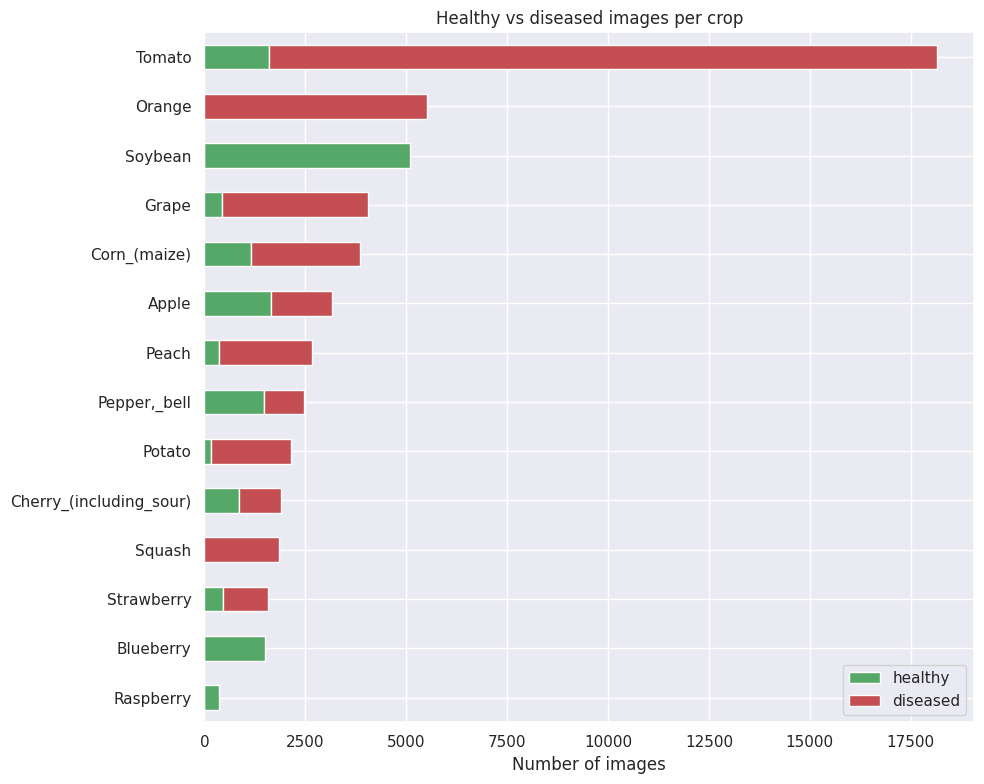

Chi-square independence (crop vs healthy/diseased): chi2 = 28005, dof = 13, p = 0.00e+00
Minimum expected count: 103.1 (valid when >= 5)

Single-condition crops (cannot learn healthy-vs-diseased):
condition  healthy  diseased
crop                        
Raspberry      371         0
Blueberry     1502         0
Squash           0      1835
Soybean       5090         0
Orange           0      5507


In [ ]:
# Figure 3 - healthy vs diseased per crop + chi-square independence
from scipy.stats import chi2_contingency

full = counts_pv.rename("n").reset_index(); full.columns = ["label", "n"]
full["crop"]      = full["label"].str.split("___").str[0]
full["condition"] = np.where(full["label"].str.split("___").str[1].str.lower().eq("healthy"),
                             "healthy", "diseased")
pivot = (full.groupby(["crop", "condition"])["n"].sum()
              .unstack(fill_value=0).reindex(columns=["healthy", "diseased"], fill_value=0))
pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]

pivot.plot(kind="barh", stacked=True, figsize=(10, 8), color=["#55a868", "#c44e52"])
plt.xlabel("Number of images"); plt.ylabel(""); plt.title("Healthy vs diseased images per crop")
plt.legend(title=""); plt.tight_layout(); plt.show()

chi2, p, dof, expected = chi2_contingency(pivot.values)
print(f"Chi-square independence (crop vs healthy/diseased): chi2 = {chi2:.0f}, dof = {dof}, p = {p:.2e}")
print(f"Minimum expected count: {expected.min():.1f} (valid when >= 5)")
print("\nSingle-condition crops (cannot learn healthy-vs-diseased):")
print(pivot[(pivot["healthy"] == 0) | (pivot["diseased"] == 0)].to_string())

**Takeaway:** crop and disease are entangled, and **five crops have only one condition** (e.g. Soybean all-healthy, Orange all-diseased). So we frame the problem as plain **38-way classification**, which sidesteps the issue.

### Figure 4 — Leaf greenness, healthy vs diseased (ANOVA)

**What / why:** compare a simple global colour number (green fraction) between healthy and diseased leaves, with an ANOVA and an effect size (η²) — to test whether *easy, hand-made features* can already separate the classes.

**How it fits:** checking whether simple features separate the classes is the classic "do we actually need deep learning?" question that exploration should answer.

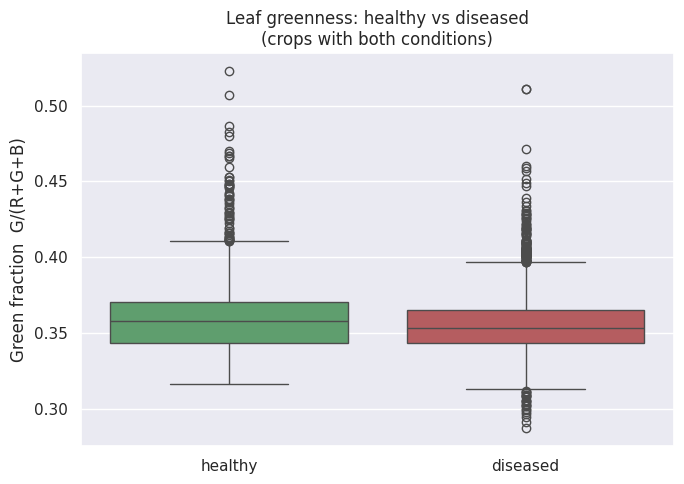

             sum_sq      df          F        PR(>F)
C(status)  0.036460     1.0  97.890268  5.954764e-23
Residual   3.035538  8150.0        NaN           NaN

ANOVA: F = 97.9, p = 5.95e-23, eta^2 = 0.012
-> significant but tiny effect: global colour barely separates; disease is LOCAL.


In [ ]:
# Figure 4 - leaf greenness, healthy vs diseased (dual-condition crops) + ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

pv["status"]     = np.where(pv["is_healthy"], "healthy", "diseased")
pv["green_frac"] = pv["mean_G"] / (pv["mean_R"] + pv["mean_G"] + pv["mean_B"])
dual = pv.groupby("crop")["is_healthy"].nunique()
sub  = pv[pv["crop"].isin(dual[dual == 2].index)]

plt.figure(figsize=(7, 5))
sns.boxplot(data=sub, x="status", y="green_frac", order=["healthy", "diseased"],
            hue="status", palette={"healthy": "#55a868", "diseased": "#c44e52"}, legend=False)
plt.xlabel(""); plt.ylabel("Green fraction  G/(R+G+B)")
plt.title("Leaf greenness: healthy vs diseased\n(crops with both conditions)")
plt.tight_layout(); plt.show()

anova = sm.stats.anova_lm(ols("green_frac ~ C(status)", data=sub).fit(), typ=2)
ss = anova["sum_sq"]; eta2 = ss["C(status)"] / ss.sum()
print(anova)
print(f"\nANOVA: F = {anova.loc['C(status)','F']:.1f}, p = {anova.loc['C(status)','PR(>F)']:.2e}, eta^2 = {eta2:.3f}")
print("-> significant but tiny effect: global colour barely separates; disease is LOCAL.")

**Takeaway:** colour barely separates them (significant but **η² ≈ 1%**). The disease signal is **local** (spots, lesions), not a global colour shift — which is exactly what a **CNN** is built to capture.

### Figure 5 — Feature correlations (Pearson)

**What / why:** a correlation heatmap of the varying numeric features — to see which carry independent information and which are redundant.

**How it fits:** understanding feature redundancy is standard EDA; here it shows how little the simple numeric features actually offer.

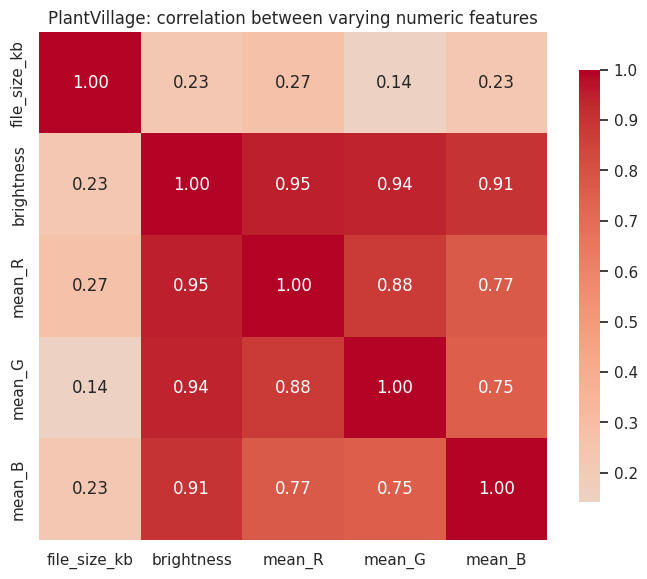

brightness vs mean_G: r = 0.94, p = 0.00e+00
mean_R vs mean_G: r = 0.88, p = 0.00e+00


In [ ]:
# Figure 5 - correlation heatmap of the VARYING numeric features + Pearson
from scipy.stats import pearsonr

var_cols = ["file_size_kb", "brightness", "mean_R", "mean_G", "mean_B"]  # sizes are constant here
plt.figure(figsize=(7, 6))
sns.heatmap(pv[var_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("PlantVillage: correlation between varying numeric features"); plt.tight_layout(); plt.show()

for a, b in [("brightness", "mean_G"), ("mean_R", "mean_G")]:
    r, p = pearsonr(pv[a], pv[b]); print(f"{a} vs {b}: r = {r:.2f}, p = {p:.2e}")

**Takeaway:** the colour features are highly redundant (effectively one "lightness" signal); file size is nearly independent but far too coarse to classify on. This confirms that only a model reading the **pixels** (a CNN) will help.

### Figure 6 — Disease signal & within-class variety

**What / why:** look at real leaves — healthy vs diseased for four crops, then several images of one class — to *see* the disease and the variety with our own eyes.

**How it fits:** looking at raw examples is the qualitative half of exploration; it sanity-checks both the data and the conclusions the numbers gave us.

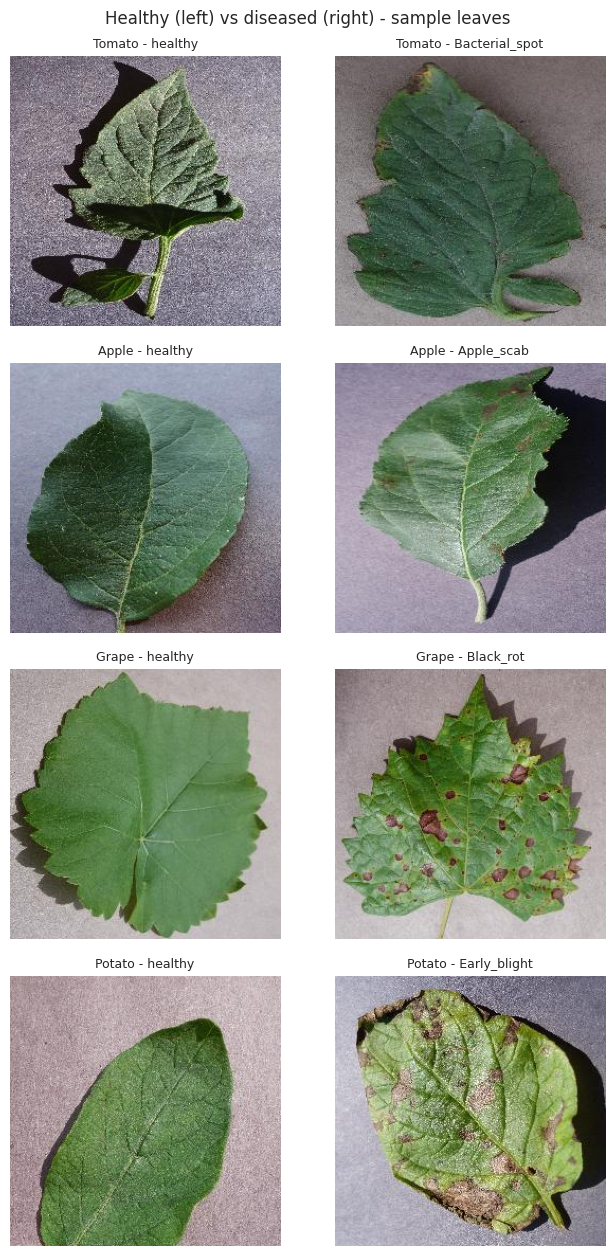

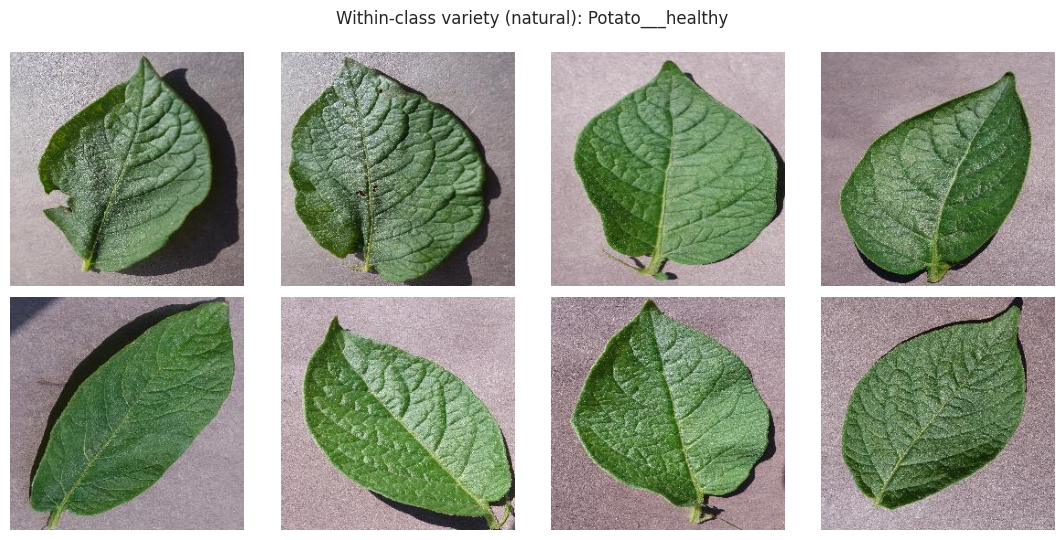

In [ ]:
# Figure 6a - healthy (left) vs diseased (right) sample leaves for four crops
show_crops = ["Tomato", "Apple", "Grape", "Potato"]
fig, axes = plt.subplots(len(show_crops), 2, figsize=(7, 3.2*len(show_crops)))
for row, crop in enumerate(show_crops):
    for col, healthy in enumerate([True, False]):
        ax = axes[row, col]
        pool = pv[(pv["crop"] == crop) & (pv["is_healthy"] == healthy)]
        if len(pool):
            ax.imshow(mpimg.imread(pool["filepath"].iloc[0]))
            lab = "healthy" if healthy else pool["label"].iloc[0].split("___")[1]
            ax.set_title(f"{crop} - {lab}", fontsize=9)
        ax.axis("off")
plt.suptitle("Healthy (left) vs diseased (right) - sample leaves", fontsize=12)
plt.tight_layout(); plt.show()

# Figure 6b - within-class variety: 8 images of one class (natural variation in the raw data)
one_class = counts_pv.index[-1]                      # a smaller class
pool = pv[pv["label"] == one_class]["filepath"].tolist()
fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
for ax, fp in zip(axes.ravel(), random.sample(pool, min(8, len(pool)))):
    ax.imshow(mpimg.imread(fp)); ax.axis("off")
plt.suptitle(f"Within-class variety (natural): {one_class}", fontsize=12)
plt.tight_layout(); plt.show()

**Takeaway:** disease shows up as **local spots/lesions** on a plain lab background — confirming the CNN choice, and flagging a **lab-vs-field gap** (clean backgrounds may not match real-world photos). The within-class variety here is *natural*, with no augmentation artefacts.

## 6. Summary

- **Structure.** ~54,305 colour images, 38 classes (14 crops x healthy/disease), uniform 256x256x3; shipped as three renderings (color / grayscale / segmented) — we use color.
- **No split, strong imbalance.** Unlike the augmented variant, the raw set has no train/valid split and is heavily imbalanced (~36:1, Figure 1). We build our own **stratified** split and handle imbalance (class weights / on-the-fly augmentation) in preprocessing.
- **Disease is local.** Global colour barely separates healthy from diseased (tiny eta^2, Figure 4); the cue is spatial (Figure 6) — the empirical case for a CNN.
- **Entangled crops.** Five crops are single-condition (Figure 3), so we treat the task as plain 38-way classification.
- **Clean-lab bias.** Plain backgrounds and even lighting (Figures 5-6) are a generalization risk; a real-world test set is the honest final check.
- **Raw vs augmented trade-off.** Raw gives full control of the split (no leakage) at the cost of more setup; the augmented set is convenient but its validation scores can be optimistic. Pick per your priority — and report the final number on un-augmented data either way.

**In short:** this completes the exploration phase — we now understand the data's structure, its biases and where the signal lives, so every preprocessing and modelling decision that follows is justified by something we found here.